# Correlation-based Template Matching

### Model fitting

A model is an informative representation of an object, person or system. It is a way of describing the object or system in terms of its properties. The problem of model fitting is fundamental in computer vision and machine learning. It can be broken down into two parts:
- Fitting: find the parameters of a model that best fit the data
- Alignment: find the parameters of the transformation that best align matched points

A model can be as simple as a line or as complex as a 3D object. In this module we will see examples of fitting models to data, starting from a simple model type, known as edge image template and then moving to more complex models.

### Template matching

What is a Template? A template is an example of how an object looks.

Template matching is a technique in digital image processing for finding small parts of an image which match a template image or a patch. The goal of template matching is to find the patch/template in an image. To find it, the user has to give two input images: Source Image (S) – The image to find the template in, and a Template Image (T) – The image that is to be found in the source image. It is basically a method for searching and finding the location of a template image in a larger image.
    
How does Template Matching Work?
- The template image simply slides over the input image (as in 2D convolution)
- The template and the patch of input image under the template image are compared.
- The result obtained is compared with the threshold.
- If the result is greater than the threshold, the portion will be marked as detected.
- In the function `cv.matchTemplate(img_gray,template,cv2.TM_CCOEFF_NORMED)` the first parameter is the main image, the second parameter is the template to be matched and the third parameter is the method used for matching, in this case we use the normalized cross-correlation.

**Note:** *A template can be thought of as the simplest possible model: a fixed exemplar that defines exactly what we expect to see. In that sense, template matching is like model fitting with zero flexibility. But in most computer vision contexts, when we say ‘model,’ we mean something parametric and adaptable, so it’s better not to confuse the two.*
- **Model fitting = finding the best parameters of a flexible family.**
- **Template matching = comparing against a rigid exemplar.**

### Sample application

Let's consider a the mobile game "Clash of Clans" where the player has to tap on the elixir icon to collect it. Let's assume we want to create a program that will load the game and collect the elixir for us from time to time. To collect do so, the program needs to find the location of the elixir icon in the screen. That can easily be done using the template matching method.

In [26]:
# Necessary imports
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

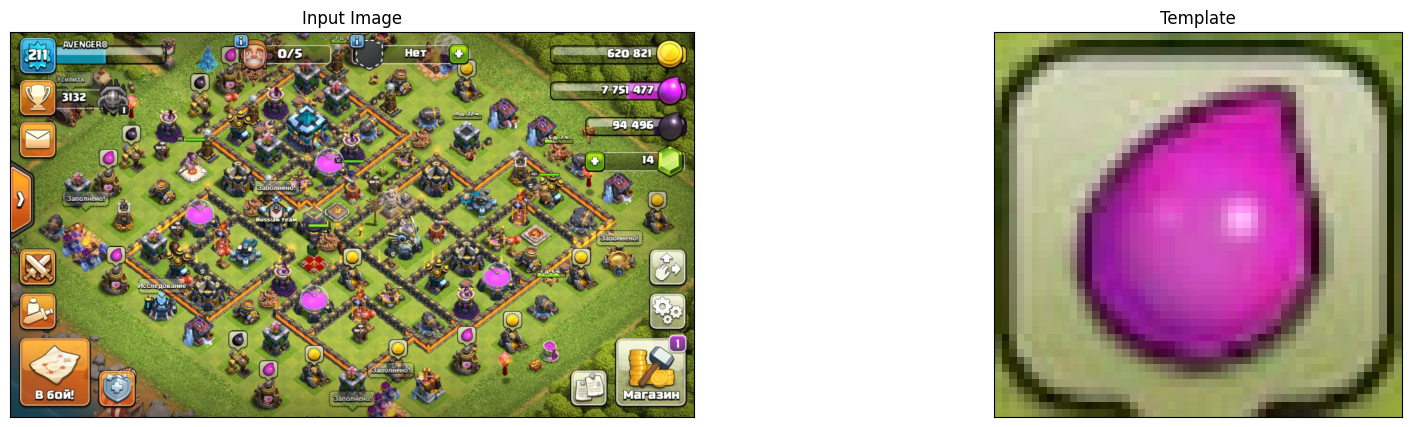

In [27]:
img = cv.imread('data/clash-of-clans-base.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
template = cv.imread('data/elixir_pump_template.jpg')
template = cv.cvtColor(template, cv.COLOR_BGR2RGB)

# Display the images
plt.figure(figsize = (20,5))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(template, cmap='gray')
plt.title('Template'), plt.xticks([]), plt.yticks([])
plt.show()

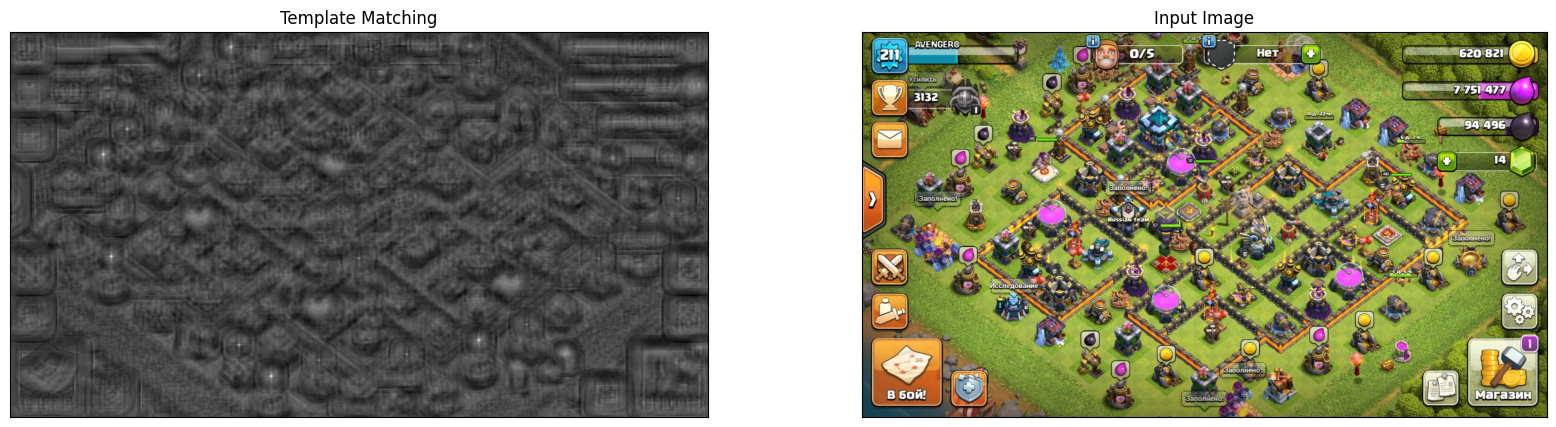

In [28]:
# Apply template Matching
result = cv.matchTemplate(img, template, cv.TM_CCOEFF_NORMED)

# Visualize the result
plt.figure(figsize = (20,5))
plt.subplot(121), plt.imshow(result, cmap='gray')
plt.title('Template Matching'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.show()

In the template matching result avobe, the more white a pixel is the better the match of the top left corner of the template with that particular location in the image. Let's check what is the maximum value of the template matching result.

In [29]:
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)

print(max_val)
print(max_loc)

0.9989621043205261
(698, 920)


We notice that the maximum value is around 0.998 and the location of the maximum value in the image is at pixel (698, 920). Let's go ahead a draw a white rectangle around the location of the best match.

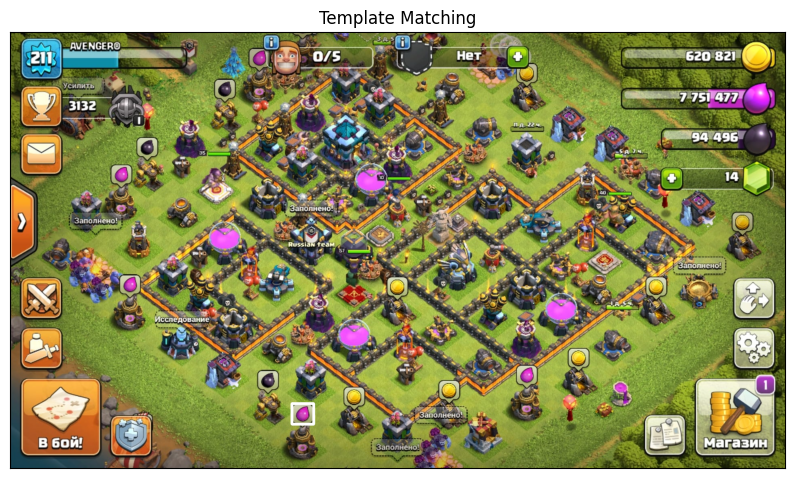

In [30]:
h, w, c = template.shape
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)
img = cv.rectangle(img, top_left, bottom_right, (255, 255, 255), 5)

# Display the image with a rectangle drawn on it
plt.figure(figsize = (10,15))
plt.imshow(img)
plt.title('Template Matching'), plt.xticks([]), plt.yticks([])
plt.show()

We can see the rectangle draw towards the bottom center of the image. The next question is, what if we want to detect not just the best match, but all the elixir icons in the image? To do so, we have to use a threhold.

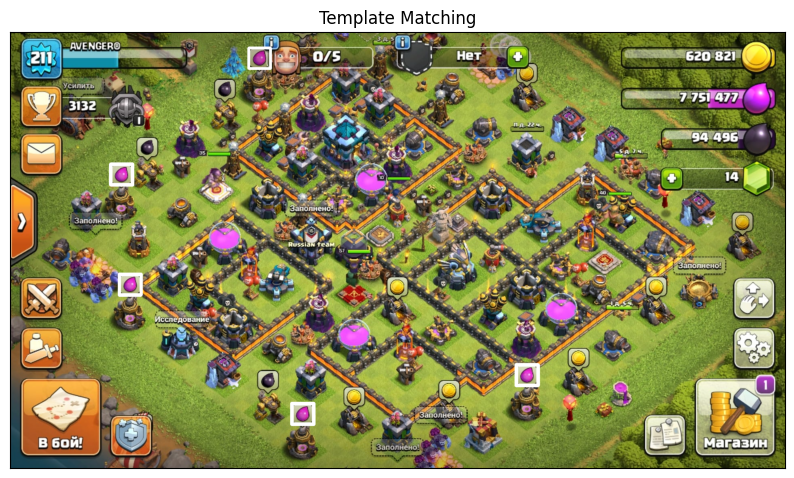

In [31]:
threshold = 0.8
loc = np.where( result >= threshold)
for pt in zip(*loc[::-1]):
    cv.rectangle(img, pt, (pt[0] + w, pt[1] + h), (255, 255, 255), 5)

# Display the image with a rectangle drawn on it
plt.figure(figsize = (10,15))
plt.imshow(img)
plt.title('Template Matching'), plt.xticks([]), plt.yticks([])
plt.show()

## Correlation-based Face Detection

In the previous example, the elixir icons that appear in the different locations of image are exact copies of the template. So, comparing them to the template using normalized cross-correlation will give us a result very close to 1.0 in all cases. Now, what if we want to use template matching to detect faces in an image? For simplicity we will only assume frontal views of faces. Different faces have more or less the same shape, but they also have differences, e.g. some people wear glasses, some people wear a hat, some people have a beard, etc. Using the face of a particular person as a template would probably work well for some people, but not for others. To create a template that is more likely to match most people, we can create an "average face" by taking the average multiple faces from a large dataset.

Let's load a few faces from our face dataset.

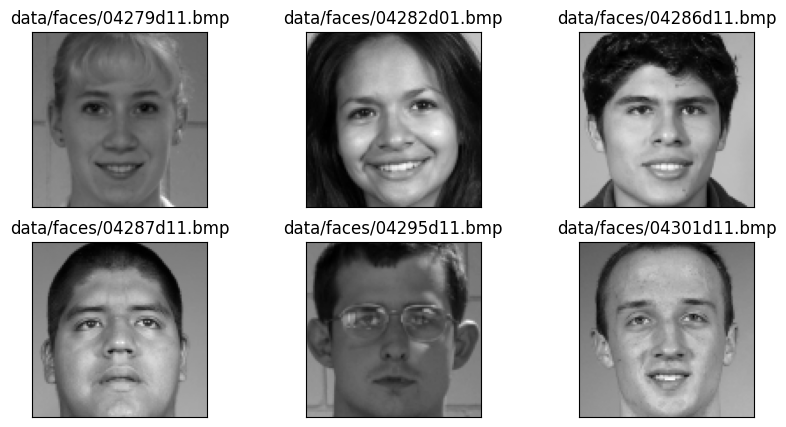

In [32]:
# Necessary imports
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt


# Load faces dataset
filenames = [
    'data/faces/04279d11.bmp', 
    'data/faces/04282d01.bmp',
    'data/faces/04286d11.bmp',
    'data/faces/04287d11.bmp',
    'data/faces/04295d11.bmp',
    'data/faces/04301d11.bmp'
    ]

# Load images
images = [cv.imread(filename,cv.IMREAD_GRAYSCALE) for filename in filenames]

# Display the images
plt.figure(figsize = (10,5))
for i in range(len(images)):
    plt.subplot(2,3,i+1), plt.imshow(images[i], cmap='gray')
    plt.title(filenames[i]), plt.xticks([]), plt.yticks([])
plt.show()

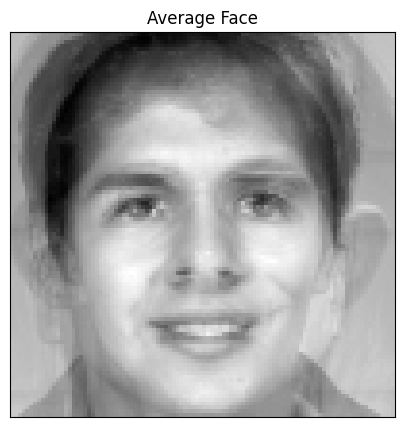

In [33]:
# Compute average face
average_face = np.zeros((images[0].shape[0], images[0].shape[1]))
for image in images:
    average_face += image
average_face /= len(images)

# Display the average face
plt.figure(figsize = (5,5))
plt.imshow(average_face, cmap='gray')
plt.title('Average Face'), plt.xticks([]), plt.yticks([])
plt.show()


The image above is the average of six faces from our dataset. Now let's compute the average face from all 337 faces in the dataset.

Number of images: 337


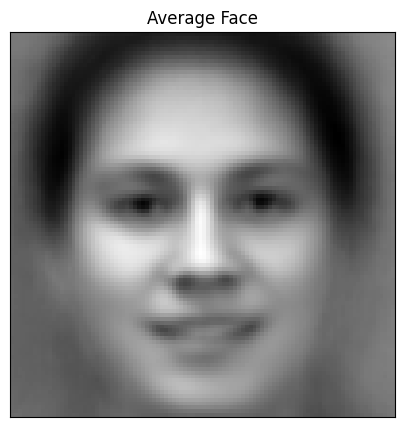

In [34]:
# Load all images in the folder data/faces
import os
filenames = [ 'data/faces/' + filename for filename in os.listdir('data/faces') ]
images = [cv.imread(filename,cv.IMREAD_GRAYSCALE) for filename in filenames]

print('Number of images:', len(images))

# Computer average face
average_face = np.zeros((images[0].shape[0], images[0].shape[1]))
for image in images:
    average_face += image
average_face /= len(images)

# Display the average face
plt.figure(figsize = (5,5))
plt.imshow(average_face, cmap='gray')
plt.title('Average Face'), plt.xticks([]), plt.yticks([])
plt.show()


The original size of the face images is 100x100 pixels. To increase the likelihood of a match, we will further crop the template and keep the parts of the average face that are most likely to be present in all faces:
- Exclude background.
- Exclude forehead (highly variable appearance, due to hair).
- Exclude lower chin.

(60, 50)


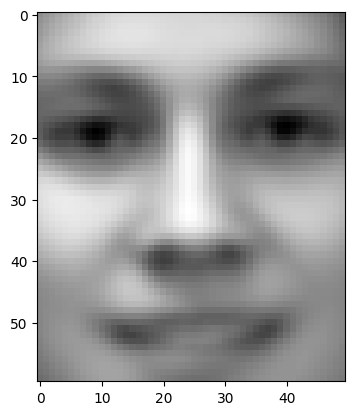

In [35]:
# Crop the average face to a square of size 60x50
average_face = average_face[25:85, 25:75]
print(average_face.shape)

plt.imshow(average_face, cmap='gray')    

We can now use the average face template to detect faces in the image. Before we do so, we need to solve one more problem. Our template is of shape (60, 50) pixels. Therefore it can only work well for faces that are of the same size. It could also be that the faces are not in exactly the upright position. To solve this problem, we need to resize the template to different scales and will also rotate it to different orientations.

### Normalized correlation

Normalized cross-correlation (NCC) is a method used primarily in image processing and computer vision for template matching and pattern recognition. The technique is employed to locate the similarity or differences between two signals or images by comparing one (usually smaller in dimension) with the other.

The standard cross-correlation of two signals (or two images) can be thought of as sliding one over the other and computing a measure of similarity at each position. However, the standard cross-correlation is sensitive to amplitude variations. This means if the amplitude of one of the signals changes, then the cross-correlation values will also change. 

Normalized cross-correlation, as the name suggests, normalizes the signals before the computation, making it robust to amplitude changes. This property makes it particularly useful in template matching in images where the pattern or template might appear with different intensities or in the presence of noise.

Mathematically, the normalized cross-correlation $ C $ of two 2D signals (or images) $ f $ and $ g $ at a position $ (x, y) $ is given by:
$$ C(x,y) = \frac{\sum_{i,j} [f(i,j) - \bar{f}][g(i+x,j+y) - \bar{g}]}{\sqrt{\sum_{i,j}[f(i,j) - \bar{f}]^2 \sum_{i,j}[g(i+x,j+y) - \bar{g}]^2}} $$
Where:
- $ \bar{f} $ and $ \bar{g} $ are the mean values of the images $ f $ and $ g $ respectively.
- The summation is over the region of the template.

The denominator in the formula ensures that the cross-correlation is normalized, and the value of $ C(x,y) $ will lie between -1 and 1. A value of 1 indicates perfect match (given the constraints of position), a value of -1 indicates a perfect inverse match, and a value of 0 indicates no match.

Applications include image registration, motion detection, and in many areas of computer vision where you need to locate specific features or patterns within a larger image.

The term "cross" in "cross-correlation" refers to the comparison or interaction between two distinct signals or datasets, rather than comparing a dataset with itself.

In mathematical and signal processing contexts:

- "Correlation" generally refers to a measure of similarity or association between two variables or datasets.
- "Auto-correlation" is when a signal is correlated with itself, typically at different time lags.
- "Cross-correlation" is when one signal (or dataset) is correlated with another distinct signal (or dataset), often to determine the degree to which the two signals match or the lag at which they match best.

In essence, the "cross" in "cross-correlation" underscores that you're looking at the interaction between two different things, not just examining one thing in relation to itself.

In the following will omit the "cross" and simply refer to "correlation" for simplicity.

In [36]:
# Normalized correlation between two vectors
def vector_normalized_correlation(v1, v2):
    # Ensure the inputs are numpy arrays
    v1 = np.array(v1)
    v2 = np.array(v2)

    # Center the vectors
    centered_v1 = v1 - np.mean(v1)
    centered_v2 = v2 - np.mean(v2)

    # Compute the correlation coefficient
    norm1 = np.linalg.norm(centered_v1)
    norm2 = np.linalg.norm(centered_v2)
    result = np.sum(centered_v1 * centered_v2) / (norm1 * norm2)
    
    return result

# Example usage:
v1 = [1, 2, 3, 4, 5]
v2 = [2, 3, 4, 5, 6]
print(vector_normalized_correlation(v1, v2))


0.9999999999999998


In [37]:
# To better understand how correlation-based template matching works, we create our own custom function to
# calculate the normalized cross correlation coefficient between an image and a template.
# This function is similar to the cv.matchTemplate(image, template, cv.TM_CCOEFF_NORMED) that we used before,
# but it is not optimized for speed and it is easier to understand.
def normalized_correlation(image, template):
    # Get the dimensions of the image and the template
    img_height, img_width = image.shape
    tpl_height, tpl_width = template.shape

    # Initialize a result matrix to store the normalized cross-correlation values
    result = np.zeros((img_height - tpl_height + 1, img_width - tpl_width + 1))

    # Compute the mean and norm for the template
    centered_template = template - np.mean(template)
    norm_template = np.linalg.norm(centered_template)

    # Slide the template over the image
    for i in range(img_height - tpl_height + 1):
        for j in range(img_width - tpl_width + 1):
            # Extract the region from the image under the template
            region = image[i:i+tpl_height, j:j+tpl_width]

            # Compute the centered region
            centered_region = region - np.mean(region)

            # Compute the normalized correlation for this position
            result[i, j] = np.sum(centered_region * centered_template) / \
                (np.linalg.norm(centered_region) * norm_template)

    return result


In [38]:
# Example usage:
image = np.array([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 10, 11, 12],
                  [13, 14, 15, 16]])

template = np.array([[6, 7],
                    [10, 11]])

print(normalized_correlation(image, template))

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


Let's see why we get all 1's in the output. Let's compute the normalized cross-correlation between the template and the top-left window of the image:

```
image = [[1, 2,  3,  4],
         [5, 6,  7,  8],
         [9, 10, 11, 12],
         [13, 14, 15, 16]]

template = [[6, 7],
            [10, 11]]

```
Centered template:

```
centered_template = template - mean(template)
                   = [[6, 7], [10, 11]] - 8.5
                   = [[-2.5, -1.5], [1.5, 2.5]]
```

Window:
    
```
window = [[1, 2],
          [5, 6]]

mean(window) = 3.5
centered_window = window - mean(window)
                 = [[1, 2], [5, 6]] - 3.5
                 = [[-2.5, -1.5], [1.5, 2.5]]
```

We notice that the centered template and centered window have exactly the same values. Therefore, the numerator of the normalized cross-correlation formula will be equal to the denominator and the result will be 1.0.

```
numerator = sum(centered_window .* centered_template)
           = (-2.5 * -2.5) + (-1.5 * -1.5) + (1.5 * 1.5) + (2.5 * 2.5)
           = 6.25 + 2.25 + 2.25 + 6.25
           = 17

norm_centered_window = sqrt(sum(centered_window^2))
                      = sqrt(6.25 + 2.25 + 2.25 + 6.25)
                      = sqrt(17)

norm_centered_template = sqrt(sum(centered_template^2))
                        = sqrt(6.25 + 2.25 + 2.25 + 6.25)
                        = sqrt(17)

denominator = norm_centered_window * norm_centered_template
             = sqrt(17) * sqrt(17)
             = 17

correlation = numerator / denominator
             = 17 / 17
             = 1
```

### Face detection with normalized correlation

Maximum value: 0.798977780922949


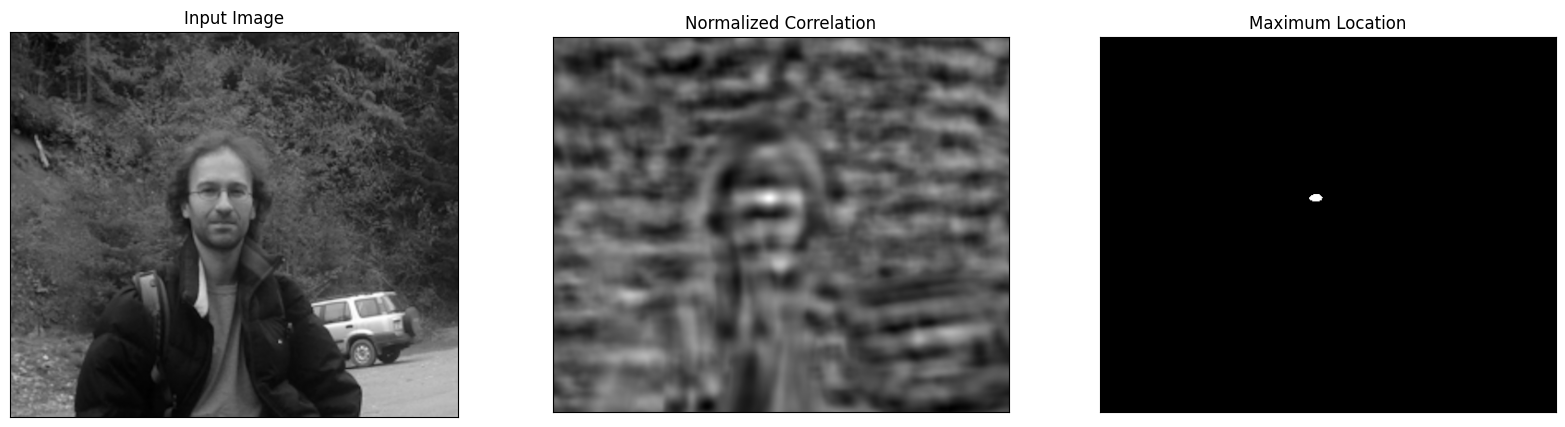

In [39]:
image = cv.imread('data/v1g.bmp', cv.IMREAD_GRAYSCALE)
result = normalized_correlation(image, average_face)

print("Maximum value:", np.max(result))

# Visualize the input image, normalized correlation result, and the location of the maximum
plt.figure(figsize = (20,5))
plt.subplot(131), plt.imshow(image, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(result, cmap='gray')
plt.title('Normalized Correlation'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(result > 0.6, cmap='gray')
plt.title('Maximum Location'), plt.xticks([]), plt.yticks([])
plt.show()


The correlation result output is a 2D array smaller than the input image: for an `H x W` image and an `h x w` template it has `H - h + 1` rows and `W - w + 1` columns. That is because the template cannot be matched with the pixels that are outside the borders of the image. Each value belongs to the top-left corner of the template, not its center: `result[y, x]` is the score of the template placed with its top-left corner at pixel `(x, y)`. 

To create an output result that is the same size as the input image, we can use the `cv2.copyMakeBorder` function to add a border of zeros around the input image before matching. The border size should be half the size of the template. After padding, `result[y, x]` is the score of the template centered on pixel `(x, y)` of the original image.

In [40]:
def zero_padding(image, tpl_height, tpl_width):
    # Calculate padding for height and width
    pad_top = tpl_height // 2
    pad_bottom = tpl_height // 2 - (tpl_height % 2 == 0)    # If tpl_height is even, pad_bottom = pad_top - 1
    pad_left = tpl_width // 2
    pad_right = tpl_width // 2 - (tpl_width % 2 == 0)       # If tpl_width is even, pad_right = pad_left - 1

    # Apply padding
    padded_image = cv.copyMakeBorder(
        image, pad_top, pad_bottom, pad_left, pad_right, cv.BORDER_CONSTANT, value=0)
    return padded_image

# Example usage:
image = np.array([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 10, 11, 12],
                  [13, 14, 15, 16]])

template = np.array([[6, 7],
                    [10, 11]])

padded_image = zero_padding(image, template.shape[0], template.shape[1])
print(normalized_correlation(padded_image, template))

[[0.70014004 0.95065415 0.98019606 0.98489164]
 [0.64705882 1.         1.         1.        ]
 [0.48186942 1.         1.         1.        ]
 [0.40572735 1.         1.         1.        ]]


Let's apply the normalized correlation to a padded version of the image.

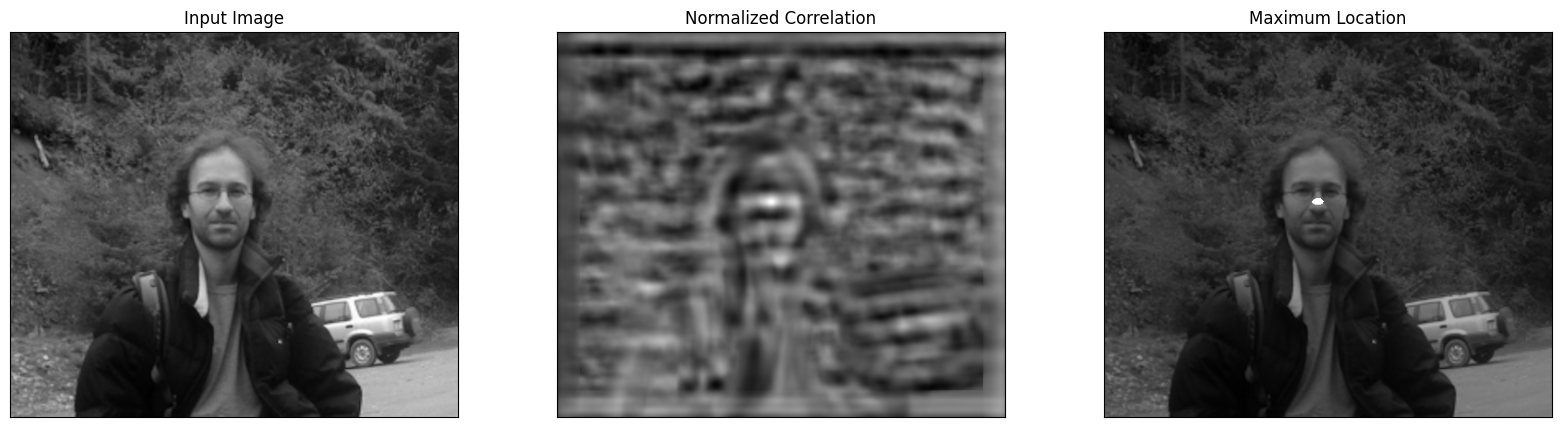

In [41]:
image = cv.imread('data/v1g.bmp', cv.IMREAD_GRAYSCALE)
padded_image = zero_padding(image, average_face.shape[0], average_face.shape[1])
result = normalized_correlation(padded_image, average_face)

# Trick to visualize the result
visualization = image.copy() * 0.7  # Darken the image
visualization[result > 0.6] = 255


plt.figure(figsize = (20,5))
plt.subplot(131), plt.imshow(image, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(result, cmap='gray')
plt.title('Normalized Correlation'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(visualization, cmap='gray')
plt.title('Maximum Location'), plt.xticks([]), plt.yticks([])
plt.show()

Let's now do the same on a zoomed in version of the image.

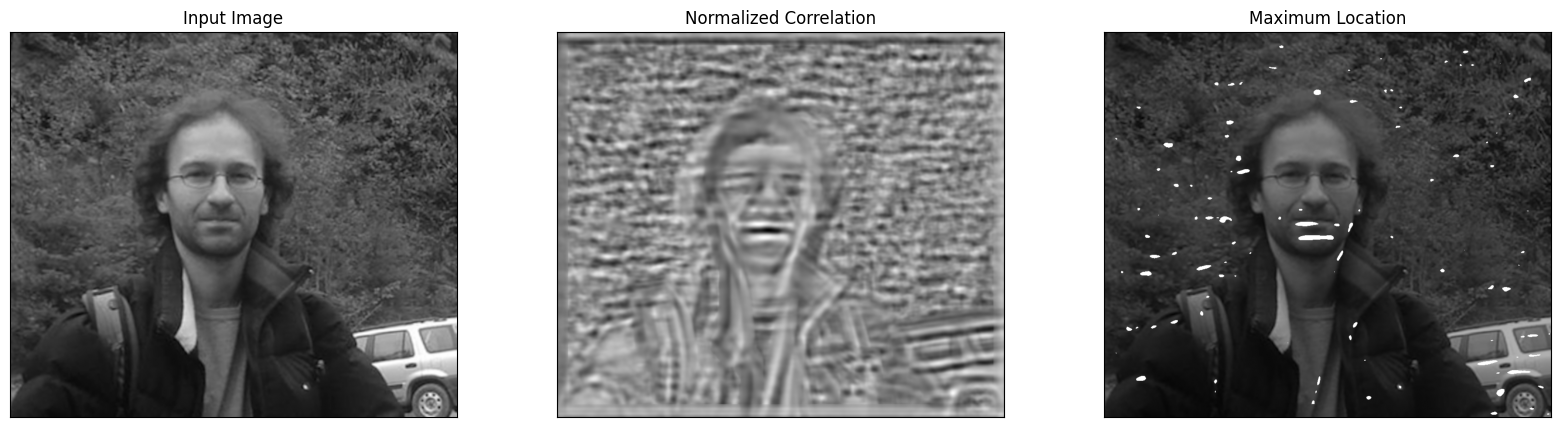

In [42]:
image = cv.imread('data/v1e.bmp', cv.IMREAD_GRAYSCALE)
padded_image = zero_padding(image, average_face.shape[0], average_face.shape[1])
result = normalized_correlation(padded_image, average_face)
visualization = image.copy() * 0.7  # Darken the image
visualization[result > 0.35] = 255


plt.figure(figsize = (20,5))
plt.subplot(131), plt.imshow(image, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(result, cmap='gray')
plt.title('Normalized Correlation'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(visualization, cmap='gray')
plt.title('Maximum Location'), plt.xticks([]), plt.yticks([])
plt.show()

### Multi-scale template matching
In the example above, template detection with the average face did not work for the zoomed in image. This is because the average face template is of a fixed size and the face in the image is much larger than the template. To solve this problem, we need to resize the template to different scales.

Implementation of a multi-scale template matching algorithm:

In [43]:
def multiscale_correlation(image, template, scales):
    # Ensure template is grayscale
    if len(template.shape) > 2 and template.shape[2] > 1:
        template = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
    
    # Initialize result matrices
    result = np.ones(image.shape, dtype=np.float32) * -10
    max_scales = np.ones(image.shape, dtype=np.float32) * -10
    
    for scale in scales:
        # Always scale the template
        scaled_template = cv.resize(template, None, fx=scale, fy=scale, interpolation=cv.INTER_LINEAR)
        
        # Pad the image to ensure the result of cv.matchTemplate has the same size as the input image
        padded_image = zero_padding(image, scaled_template.shape[0], scaled_template.shape[1])
        
        # Ensure both images are of the same type
        if padded_image.dtype != scaled_template.dtype:
            scaled_template = scaled_template.astype(padded_image.dtype)
        
        current_result = cv.matchTemplate(padded_image, scaled_template, cv.TM_CCOEFF_NORMED)
        
        # Update the result and max_scales matrices
        higher_maxes = current_result > result
        max_scales[higher_maxes] = scale
        result[higher_maxes] = current_result[higher_maxes]
    
    return result, max_scales


Template matching at scale range from 0.5 to 3.0.

Maximum value: 0.79696655
Best scale: 2.9


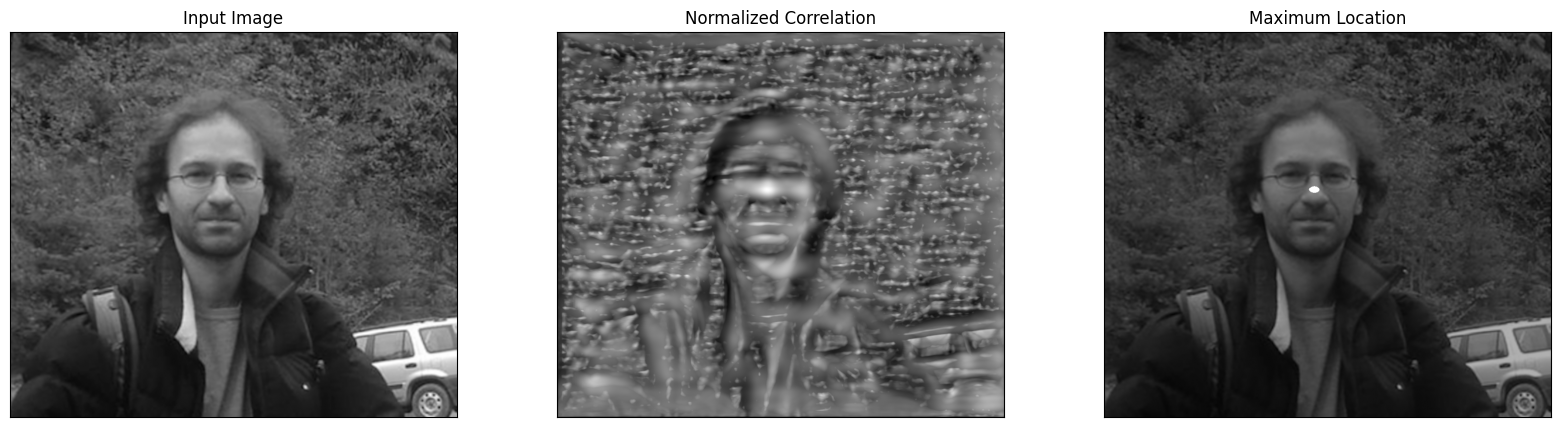

In [44]:
image = cv.imread('data/v1e.bmp', cv.IMREAD_GRAYSCALE)
scales = np.arange(0.5, 3.1, 0.1) # Scales to try [0.5, 0.6, ..., 3.0]
result, max_scales = multiscale_correlation(image, average_face, scales)

print('Maximum value:', np.max(result))
index = np.unravel_index(np.argmax(result), result.shape)
print('Best scale:', max_scales[index])

visualization = image.copy() * 0.7  # Darken the image
visualization[result > 0.7] = 255

plt.figure(figsize = (20,5))
plt.subplot(131), plt.imshow(image, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(result, cmap='gray')
plt.title('Normalized Correlation'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(visualization, cmap='gray')
plt.title('Maximum Location'), plt.xticks([]), plt.yticks([])
plt.show()

### Multi-rotation template matching

Besides searching at multiple scales, we can also search at multiple rotations. This is useful when the template is not upright in the image. In our case, the average face template is upright, but the faces in the image may not be upright. To solve this problem, we need to rotate the template to different orientations.

In [45]:
# Auxiliary function to rotate an image
def rotate(image, angle, center = None):
    (h, w) = image.shape[:2]

    if center is None:
        center = (w / 2, h / 2)

    # Perform the rotation
    M = cv.getRotationMatrix2D(center, angle, scale = 1.0)
    rotated = cv.warpAffine(image, M, (w, h), flags=cv.INTER_LINEAR, borderMode=cv.BORDER_REPLICATE)

    return rotated

In [46]:
# Template search at multiple scales and rotations
def template_search(image, template, scales, rotations):
    # Initialize matrices to keep track of maximum responses, scales, and rotations
    max_responses = np.ones(image.shape, dtype=np.float32) * -10
    max_scales = np.ones(image.shape, dtype=np.float32) * -10
    max_rotations = np.ones(image.shape, dtype=np.float32) * -10

    # Loop over each rotation
    for angle in rotations:
        rotated_template = rotate(template, angle)
        
        # Obtain correlation for the current rotation
        current_responses, current_scales = multiscale_correlation(image, rotated_template, scales)
        
        # Update the matrices where the current response is greater than the previous maximum
        higher_maxes = current_responses > max_responses
        max_responses[higher_maxes] = current_responses[higher_maxes]
        max_scales[higher_maxes] = current_scales[higher_maxes]
        max_rotations[higher_maxes] = angle

    return max_responses, max_scales, max_rotations


The function template_detector_demo below implements a multi-scale and multi-rotation template matching algorithm.

In [47]:
def compute_bbox(x, y, template_shape, scale):
    width = int(template_shape[1] * scale)
    height = int(template_shape[0] * scale)
    topLeft = (x - width // 2, y - height // 2)
    bottomRight = (x + width // 2, y + height // 2)
    return topLeft, bottomRight

def suppress_detection(max_responses, x, y, width, height):
    half_height, half_width = height // 2, width // 2
    max_responses[max(0, y - half_height):min(max_responses.shape[0], y + half_height + 1),
                  max(0, x - half_width):min(max_responses.shape[1], x + half_width + 1)] = 0

def template_detector_demo(image, template, scales, rotations, result_number=None, threshold=None):
    max_responses, max_scales, max_rotations = template_search(image, template, scales, rotations)
    
    # Set up defaults
    max_response_value = np.max(max_responses)
    default_threshold = -np.inf if result_number else threshold
    default_count_limit = float('inf') if result_number is None else result_number

    final_boxes = []
    count = 0
    
    while max_response_value > default_threshold and count < default_count_limit:
        y, x = np.unravel_index(np.argmax(max_responses), max_responses.shape)
        scale, rotation = max_scales[y, x], max_rotations[y, x]

        print('Detected face at scale', scale, 'and angle', rotation, 'with confidence', max_responses[y, x])
        topLeft, bottomRight = compute_bbox(x, y, template.shape, scale)
        final_boxes.append((topLeft, bottomRight))

        # Suppress detections in the neighborhood of the current maximum
        suppress_detection(max_responses, x, y, bottomRight[0] - topLeft[0], bottomRight[1] - topLeft[1])
        count += 1
        max_response_value = np.max(max_responses)

    result_image = image.copy()
    for box in final_boxes:
        cv.rectangle(result_image, box[0], box[1], 255, 2)

    return result_image, final_boxes


Detected face at scale 0.3 and angle 0.0 with confidence 0.61579955


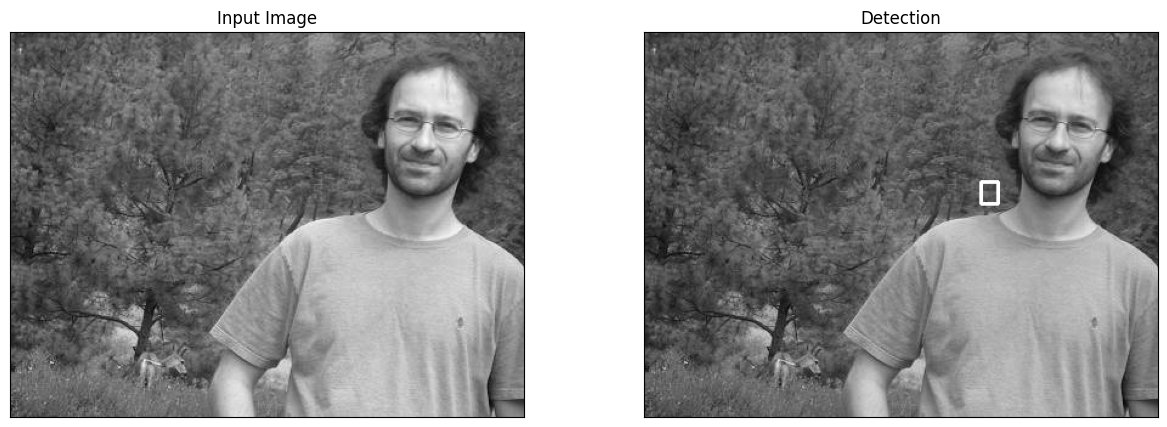

In [48]:
image = cv.imread('data/v2b.bmp', cv.IMREAD_GRAYSCALE)
scales = np.arange(0.3, 3.1, 0.1) # Scales to try [0.3, 0.4, ..., 3.0]
rotations = [0]                   # No rotations
result = template_detector_demo(image, average_face, scales, rotations, result_number=1)

plt.figure(figsize = (15,5))
plt.subplot(121), plt.imshow(image, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(result[0], cmap='gray')
plt.title('Detection'), plt.xticks([]), plt.yticks([])
plt.show()


Detected face at scale 1.0 and angle -12.0 with confidence 0.7162232


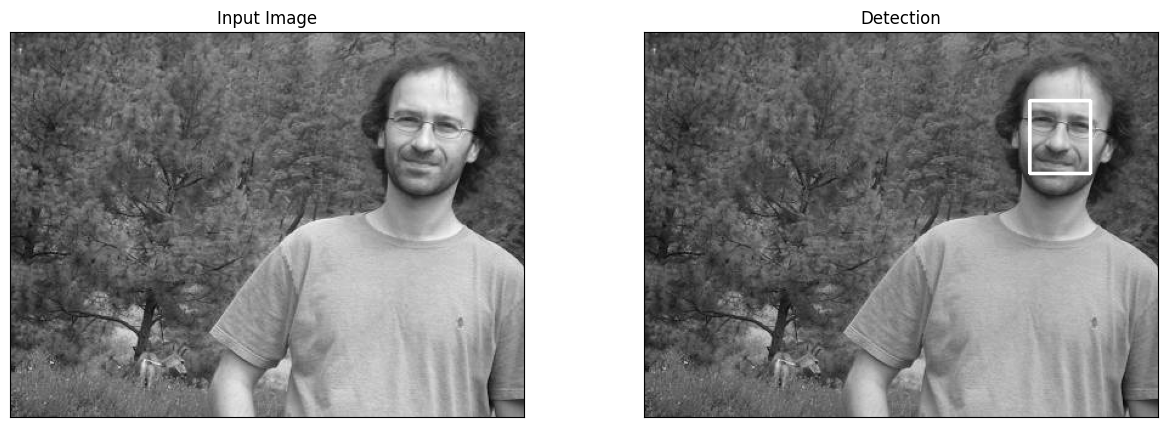

In [49]:
image = cv.imread('data/v2b.bmp', cv.IMREAD_GRAYSCALE)
scales = np.arange(0.3, 3.1, 0.1) # Scales to try [0.3, 0.4, ..., 3.0]
rotations = np.arange(-20, 21, 2) # Rotations to try [-20, -18, ..., 20]
result = template_detector_demo(image, average_face, scales, rotations, result_number=1)

plt.figure(figsize = (15,5))
plt.subplot(121), plt.imshow(image, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(result[0], cmap='gray')
plt.title('Detection'), plt.xticks([]), plt.yticks([])
plt.show()

Let's now apply the multi-scale and multi-rotation template matching to an image with multiple faces.

Detected face at scale 0.5 and angle 3.0 with confidence 0.62814206
Detected face at scale 0.5 and angle -6.0 with confidence 0.60963243
Detected face at scale 0.7 and angle -10.0 with confidence 0.6094385
Detected face at scale 0.5 and angle 7.0 with confidence 0.6078672
Detected face at scale 0.5 and angle -3.0 with confidence 0.59334725


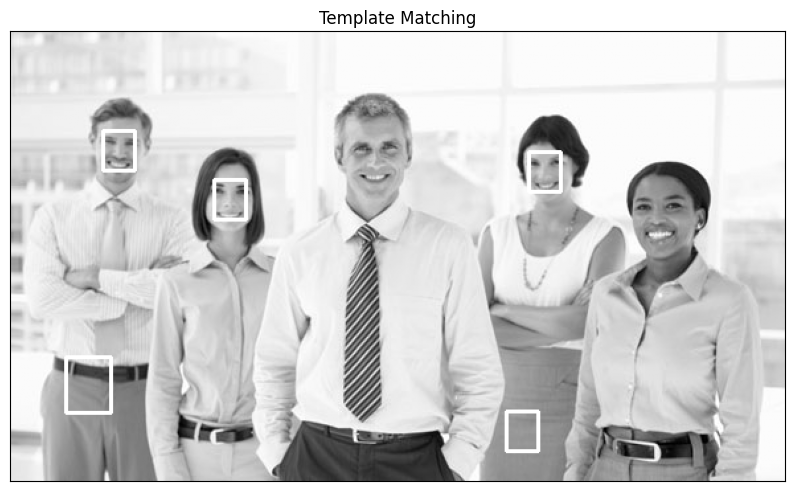

In [50]:
img = cv.imread('data/faces.jpg', cv.IMREAD_GRAYSCALE)

scales = np.arange(0.5, 2, 0.1)
rotations = np.arange(-10, 10, 1)

result, boxes = template_detector_demo(img, average_face, scales, rotations, None, 0.59)

plt.figure(figsize = (10,15))
plt.imshow(result, cmap='gray')
plt.title('Template Matching'), plt.xticks([]), plt.yticks([])
plt.show()

We notice that with a threshold of 0.59 only three of the faces are detected, but we also get a two false positives. If we lower the threshold, we will likely detect more faces, but will also probably get more false positives, i.e. areas of the image that are not faces will be detected as faces. 

Normalized correlation is a good method to detect for detecting objects that are stable in their appearance. Although faces can be detected with this method, it is not the best face detection method. Methods like Haar-cascade or Viola-Jones  and Deep Learning models are much more accurate.